<center> 

# DSSI: Summer 2024
    
## Classification: Part I

#### Authored by: Susanna Lange, PhD


<center>
<img src="https://raw.githubusercontent.com/amandakube/Data118LectureImages/main/UChicago_DSI.png" alt="UC-DSI" width="300" height="100">
</center>



In [25]:
import numpy as np
import pandas as pd
%matplotlib inline


import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import matplotlib.patches as mpatches

### Goal of this notebook

Classification!

 - One approach to classification!
    
     - K Nearest Neighbor Algorithm
 
 - Focus on ideas surrounding
     - Tuning Parameters
     - Measures of Determining a 'Good' model

# Classification: prediction of a categorical response.


**Classification** refers to the assigning of a label, a finite collection of categorical values, to an unlabeled example, given previous labeled data.

# K- Nearest Neighbor (Idea)


<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/knn_dogcat0.png" alt="knn_graph1" width="500">


<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/knn_dogcat1.png" alt="knn_graph2" width="500">


<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/knn_dogcat2.png" alt="knn_graph3" width="500">

# k-Nearest Neighbor (kNN) Classifier


We can classify a new point based on the k- nearest neighbors! This algorithm uses information about a data point's k nearest neighbors to classify this new data point. 
The basic structure of the algorithm is outlined below:

Given a collection of labeled data points, $\mathcal{D} = \{(x,y)_i\}_{i=1}^n$, a value for $k$, and a distance metric, $d(p,q)$ we classify a new data point $z$ in the following way:
1. Calculate the distance $d(p,z)$ for each point $p$ in the dataset
2. Find the $k$ smallest values of $d(p,z)$
3. Classify $z$ dependent on the mode, or most often, classification of it's $k$ nearest neighbors.

Decisions:
- Need to define the distance between attributes (features, predictors)
- Need to find a choice of k

Properties:
- Simplicity (easy to implement, no assumptions)
- Works well for low dimensional data (low number of features)

### Choice of distance metric

The most commonly used distance is the **Euclidean distance**. This distance metric calculates the shortest line distance between points in the $xy$ coordinate plane and comes from the Pythogorean theorem.

Given points $p = (x_1, y_1)$,  $q = (x_2, y_2)$, we define the distance between these points as  
$$d(p,q) = \sqrt{(x_1-x_2)^2 + (y_1-y_2)^2}$$



This distance extends to multiple dimensions or multiple features $n$. In general, we have two points $p = (x_1, x_2, ..., x_n)$ and $q = (z_1, z_2, ..., z_n)$, the Euclidean distance is computed as

$$d(p,q) = \sqrt{(x_1-z_1)^2 + (x_2-z_2)^2+ ...(x_n-z_n)^2}$$

**Manhattan distance**, often called the taxicab distance, measures the distance between two points

Given points $p = (x_1, y_1)$,  $q = (x_2, y_2)$, we define the distance between these points as  
$$|x_1-x_2|+|y_1-y_2|,$$

which can also be extended to higher dimensions. For $n$ dimensions, with given input of two points $p = (x_1, x_2, ..., x_n)$ and $q = (z_1, z_2, ..., z_n)$, the distance is defined to be

$$d(p,q) = |x_1-z_1| + |x_2-z_2|+ ...|x_n-z_n|.$$

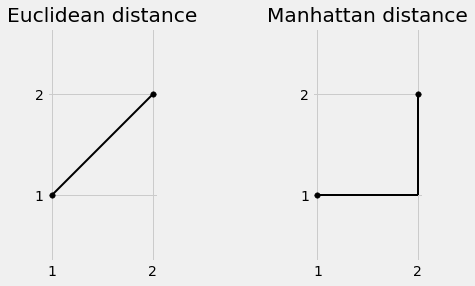

In [26]:
#code not important here

plt.subplot(1, 3, 1)
plt.plot((1, 2),(1,2),'black', linewidth=2);
plt.scatter(1,1 , color='black', s=30);
plt.scatter(2,2 , color='black', s=30);
plt.xticks([1,2])
plt.yticks([1,2])
plt.axis('equal');
plt.title("Euclidean distance");

plt.subplot(1, 3, 3)

plt.plot((1, 2),(1,1),'black', linewidth=2);
plt.plot((2, 2),(1,2),'black', linewidth=2);
plt.scatter(1,1 , color='black', s=30);
plt.scatter(2,2 , color='black', s=30);
plt.xticks([1,2])
plt.yticks([1,2])
plt.axis('equal');
plt.title("Manhattan distance");


#### For each of these distance metrics scaling/standardizing your variables is important!! Why?

**Cosine Similarity**

Given points $p = (x_1, y_1)$,  $q = (x_2, y_2)$, we define the distance between these points as  
$$\cos(\theta),$$
where $\theta$ is the angle between the two vector representations of the points.

By *vector representation*, we mean that each point has 

- a direction

- a magnitude

(More on this later)

<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/cosine.png" alt="cosine" width="900">

Image Credit: https://www.learndatasci.com/glossary/cosine-similarity/

## In code

We will use sklearn to implement this algorithm!

```python 
from sklearn.neighbors import KNeighborsClassifier


neigh = KNeighborsClassifier(n_neighbors=k)

neigh.fit(X, y)


neigh.predict(new_data)
```

We input 

- k (number of neighbors)

- X (the data!!) 

- y (the label!)

- new_data


Documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

## Example

In [27]:
## This contains simulated data
# you can ignore this code
np.random.seed(seed=1243)
dog_ears = np.random.normal(loc=2.5, scale=2.25, size=20)

cat_ears = np.random.normal(loc=6, scale=1.5, size=20)
cat_claws = np.random.normal(loc=5, scale=2, size=20)

dog_claws = np.random.normal(loc=3.5, scale=1.56, size=20)
animal_labels = np.concatenate((np.full((20, ), ['dog']),  np.full((20, ), ['cat'])))

characteristic_df = pd.DataFrame({'claw sharpness': np.concatenate((dog_claws, cat_claws)),
              'ear pointiness': np.concatenate((dog_ears, cat_ears)), 'Label': animal_labels})
characteristic_df = characteristic_df.sample(frac=1).reset_index(drop=True)


In [28]:
characteristic_df.head()

,claw sharpness,ear pointiness,Label
0,3.825685,6.406667,cat
1,4.763658,1.951387,dog
2,6.329188,5.066956,cat
3,2.824689,1.649148,dog
4,5.949133,4.280015,cat


First step: Standardize your training data!
    
    
(x - np.average(x))/np.std(x)

In [29]:
from sklearn.preprocessing import StandardScaler
data = characteristic_df[['claw sharpness','ear pointiness']]


scaler = StandardScaler()
scaler.fit(data) #Computes the mean and std to be used for later scaling.
scaled_X = scaler.transform(data) #does the transformation for each value
scaled_X[0:5] #prints out first 5

array([[-0.16515745,  1.00443973],
       [ 0.32395292, -1.09454326],
       [ 1.14030567,  0.3732716 ],
       [-0.68713079, -1.23693493],
       [ 0.94212433,  0.0025258 ]])

In [30]:
from sklearn.neighbors import KNeighborsClassifier

In [31]:
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(scaled_X, characteristic_df.Label) #inputs the data

KNeighborsClassifier(n_neighbors=3)

In [32]:
new_data = pd.DataFrame({'claw sharpness': [0.3, -.2], 'ear pointiness': [0, 1.2]})
new_data 

,claw sharpness,ear pointiness
0,0.3,0.0
1,-0.2,1.2


In [33]:
neigh.predict(new_data.values) #.values extracts the DataFrame as an array!

array(['cat', 'cat'], dtype=object)

## Let's visualize this!

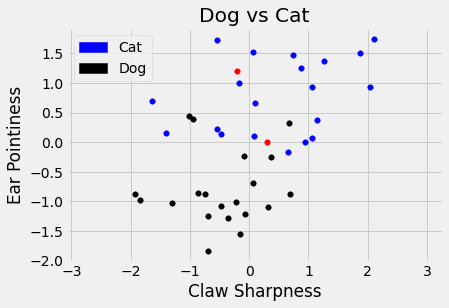

In [34]:
#code not important here either
cat_indx = characteristic_df.index[characteristic_df['Label'] == 'cat'].tolist()
dog_indx = characteristic_df.index[characteristic_df['Label'] == 'dog'].tolist()

plt.scatter(scaled_X[cat_indx][:,0],scaled_X[cat_indx][:,1], color='blue', s=30)
plt.scatter(scaled_X[dog_indx][:,0], scaled_X[dog_indx][:,1] , color='black', s=30);
blue_patch = mpatches.Patch(color='blue', label='Cat')
black_patch = mpatches.Patch(color='black', label='Dog')

plt.scatter(0.3,0.0 , color='red', s=30);
plt.scatter(-0.2,1.2 , color='red', s=30);
plt.axis('equal')
plt.legend(handles=[blue_patch, black_patch])
plt.title("Dog vs Cat")
plt.ylabel('Ear Pointiness')
plt.xlabel('Claw Sharpness');

### Questions that remain:

1. We might wonder **Is there a sense of accuracy for this algorithm?** Or some measure of how good this model is? 

2. **How do we choose a value for k in a general classification problem?** 

**Is there a sense of accuracy for this algorithm?** Or some measure of how good this model is? 

There are various measures of model fit.

- Accuracy
- Sensitivity
- Specificity
- Precision

(Note there are other metrics not mentioned here that are also useful. Your metric depends on the model)

## Confusion Matrix

When making predictions, there are four possible outcomes:

<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/confusion_matrix.png" alt="confusion_matrix" width="900">

## Accuracy

The overall accuracy of a classifier is
$$Accuracy = \frac{True Positives + True Negatives}{n}$$

Accuracy always falls between 0 and 1, with values closer to 1 being more desirable.


## Sensitivity (called Recall)

The sensitivity, or true positive rate (TPR) of a classifier is

 $$TPR = \frac{True Positives}{True Positives + False Negatives} = \frac{True Positives}{Total Positives}$$

How many of the true positive cases did the classifier catch?

TPR always falls between 0 and 1, with values closer to 1 being more desirable.


## Precision 

Out of all the examples that predicted as positive, how many are really positive?
    
$$Precision = \frac{True Positives}{True Positives + False Positive} = \frac{True Positives}{Total Predicted Positives}$$

## Specificity

The specificity, or true negative rate (TNR) of a classifier is 
       
 $$TNR = \frac{True Negatives}{True Negatives + False Positives}$$

How many of the true negative cases did the classifier catch?

TNR always falls between 0 and 1, with values closer to 1 being more desirable.


Why so many??

Suppose from population we choose sample of 10. Below we see an accuracy of 80% (8/10).

<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/metric_example1.png" alt="metric_ex" width="900">

Image Credit: https://jeff.wintersinger.org/posts/2021/02/a-probabilistic-perspective-on-binary-classification-metrics/

**Our data is unbalanced!**

Below we see an accuracy of 90% (9/10). Is this a good model?

<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/metrics_example2.png" alt="metric_ex" width="900">

Image Credit: https://jeff.wintersinger.org/posts/2021/02/a-probabilistic-perspective-on-binary-classification-metrics/

### F1 Score
One more measure!

Can be thought of as a weighted averaged of precision and recall.

$$F1 Score = \frac{2\cdot TP}{2 \cdot TP+FP+FN}$$

#### <code style="background:Thistle;color:black">Example: Activity!</code>

Suppose we are interested in predicting COVID. Has COVID is encoded as 1 and does not have COVID is encoded as 0. My predictions are $$\hat{y} = \begin{bmatrix}
1\\
1 \\
1\\
0 \\
0\\
0
\end{bmatrix}$$  and the actual labels are $$y  = \begin{bmatrix}
0\\
1 \\
1\\
1\\
0\\
1
\end{bmatrix}.$$

<code style="background:Thistle;color:black">Fill in the blanks to construct the confusion matrix for this data.</code>


| Predicted/Truth | Negative (0) | Positive (1)|
| --- | --- | --- |
| Negative (0)  | ??? | ??? |
| Positive (1) | ??? | ???|

<code style="background:Thistle;color:black">What is the accuracy?</code>


answer here

<code style="background:Thistle;color:black">What is the sensitivity?</code>
Out of all the people that have the disease, how many got positive test results?

answer here

<code style="background:Thistle;color:black">What is the specificity?</code>
Out of all the people that do not have the disease, how many got negative results?

answer here

<code style="background:Thistle;color:black">What is the precision?</code>
Out of all the examples that predicted as positive, how many are really positive?

answer here

Stop here!

### In code:

In [35]:
new_data = pd.DataFrame({'claw sharpness': [0.3, -.2, -0.2, 1, -2], 'ear pointiness': [0, 1.2, -0.5, 3,-0.3]})
new_data_actual = np.array(['cat', 'cat', 'dog', 'dog', 'dog'])


predicted = neigh.predict(new_data.values) #.values extracts the DataFrame as an array!
predicted 

array(['cat', 'cat', 'dog', 'cat', 'dog'], dtype=object)

Need to convert to binary to get metrics! (Note this is often done first, before creating a model)

Set dog = 1, and cat = 0

In [36]:
def convert_bool(input_label):
    '''Converts to numerical encoding'''
    if input_label == 'dog':
        return 1
    else: 
        return 0

**here we want to apply a function to an array!**

```python 
np.vectorize()
```

Will convert a function that works on a single input, to one that works elementwise on an entire array

In [37]:
predicted_bool = np.vectorize(convert_bool)(predicted)
print(predicted_bool)

new_data_actual_bool = np.vectorize(convert_bool)(new_data_actual)
print(new_data_actual_bool)

[0 0 1 0 1]
[0 0 1 1 1]


In [38]:
from sklearn import metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

To use these measures, we input ground_truth (the actual labels) and predictions (the predicted values)

```python 
accuracy = accuracy_score(ground_truth, predictions)

recall = recall_score(ground_truth, predictions)

precision = precision_score(ground_truth, predictions)

f_1 = f1_score(ground_truth, predictions)


```

In [39]:
accuracy = accuracy_score(new_data_actual_bool, predicted_bool)

recall = recall_score(new_data_actual_bool, predicted_bool)

precision = precision_score(new_data_actual_bool, predicted_bool)

f1= f1_score(new_data_actual_bool, predicted_bool)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)

Accuracy: 0.8
Recall: 0.6666666666666666
Precision: 1.0
f1_score: 0.8


## How do we choose k??

<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/knn_whichk.png" alt="metric_ex" width="600">

Image Credit: https://ai.plainenglish.io/introduction-to-k-nearest-neighbors-knn-algorithm-e8617a448fa8

## Bias–Variance Tradeoff

Bias: the difference between the true label and our prediction
    
   - Large difference $\rightarrow$ bias is large
   
   
Variance: variability in the model prediction

  - Large variance $\rightarrow$ large spread of outputs

<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/bias_variance.png" alt="bias/var" width="600">

Image Credit: https://medium.com/stat-man/everything-you-need-to-know-about-bias-and-variance-76b30da9eb39

### Overfitting and Underfitting a model

Bias and Variance

Underfitting: the model does not fit, does not predict, the (training) data very well.
Overfitting: the model predicts the (training) data too well!

Normally, underfitting implies high bias and low variance, and overfitting implies low bias but high variance.

<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/overfitting_underfitting.png" alt="under_overfit" width="800">

Image Credit: https://medium.com/stat-man/everything-you-need-to-know-about-bias-and-variance-76b30da9eb39

## We want to create a model that achieves a balance.

<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/bias_variance_graph.png" alt="bias_var" width="800">

Image Credit: https://medium.com/ai-enthusiast/the-two-towers-of-machine-learning-conquering-bias-and-variance-ad4cf20955bc

### As we increase k

 - Bias is reduced

 - Variance is increased


<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/decision_bound_1.png" alt="decision" width="500">

<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/decision_bound2.png" alt="decision" width="500">

#### train/val/test split

kNN - Often called 'lazy learner'

There is not any 'training' because we are not trying to iteratively minimize something - no task to learn.


Here think of 'training data' as all of the data that will determine the classification.

Uses all 'training data' to classify new points.


<img src="https://raw.githubusercontent.com/SusannaLange/Data_118_images/main/DSSI_images/machine_learning_classification/train_val_test.png" alt="train_val_test" width="500">

We need a validation set: Need to choose k. And a test set to evaluate our chosen model.

In [40]:
from sklearn.model_selection import train_test_split
characteristic_df.shape

(40, 3)

In [41]:
X_train, X_test, y_train, y_test \
    = train_test_split(X, y, test_size=0.2, random_state=1)

X_train, X_val, y_train, y_val \
    = train_test_split(X_train, y_train, test_size=0.25, random_state=1) # 0.25

NameError: name 'X' is not defined

In [42]:
X = characteristic_df[['claw sharpness','ear pointiness']]
y = np.vectorize(convert_bool)(characteristic_df['Label'])


#Testing and Training split
X_train, X_test, y_train, y_test \
    = train_test_split(X, y, test_size=0.2, random_state=6, shuffle = True)


#Training and Val split
X_train, X_val, y_train, y_val \
    = train_test_split(X_train, y_train, test_size=0.3, random_state=6, shuffle = True) 

Note: You will see **cross validation** later, which is more robust for small data, later. Now we focus on one method of splitting the data for our model.

In [24]:
my_k = [1,3,5,7]

my_scores = []

for i in my_k:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    predicted = knn.predict(X_val)
    my_scores.append(f1_score(y_val,predicted))

In [23]:
my_scores

[0.7499999999999999, 0.8571428571428571, 1.0, 0.8571428571428571]

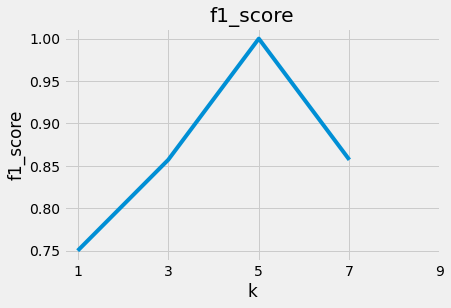

In [24]:
plt.plot(my_k, my_scores)
plt.xlabel('k')
plt.xticks(np.arange(1,10,2))
plt.ylabel('f1_score')
plt.title('f1_score')
plt.show()

From this, we see k = 5 gives the best score.

Evaulate on the test set

In [25]:
knn_best = KNeighborsClassifier(n_neighbors=5)
knn_best.fit(X_train, y_train)
predicted = knn_best.predict(X_test)

f1_score(y_test,predicted)

0.6666666666666666

In [26]:
accuracy = accuracy_score(y_test,predicted)

recall = recall_score(y_test,predicted)

precision = precision_score(y_test,predicted)

f1= f1_score(y_test,predicted)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)

Accuracy: 0.75
Recall: 0.5
Precision: 1.0
f1_score: 0.6666666666666666


### <code style="background:Thistle;color:black">Activity</code>

Welcome to the year 2912, where your data science skills are needed to solve a cosmic mystery. We've received a transmission from four lightyears away and things aren't looking good.

The Spaceship Titanic was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on its maiden voyage transporting emigrants from our solar system to three newly habitable exoplanets orbiting nearby stars.

While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension!



To help rescue crews and retrieve the lost passengers, you are challenged to predict which passengers were transported by the anomaly using records recovered from the spaceship’s damaged computer system.

Help save them and change history!


** This activity is taken from Kaggle:
Addison Howard, Ashley Chow, Ryan Holbrook. (2022). Spaceship Titanic. Kaggle. https://kaggle.com/competitions/spaceship-titanic

Please note the data has been cleaned slightly for use in this notebook.

Variable description:

PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.

HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.

CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.

Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.

Destination - The planet the passenger will be debarking to.

Age - The age of the passenger.

VIP - Whether the passenger has paid for special VIP service during the voyage.

RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.

Name - The first and last names of the passenger.

Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

We will be using a kNN model to help us predict a class!

Read in the data.

In [2]:
space_df = pd.read_csv('space_data.csv')
space_df.head()

NameError: name 'pd' is not defined

**Question 1**: We want to use the numerical variables: 'Age','RoomService','FoodCourt','ShoppingMall', 'Spa'. Our predicted output will be 'transported.

Create a collection of these features and store them in variable 'x'. Convert the transported column to 0/1 values: 1 = yes, 0 = no, and store that in variable 'y'.

In [ ]:
## code here

In [1]:
#more space here

**Question 2:** Split the data into 3 parts: a training set, a validation set, and a test set.

In [ ]:
## code here

In [1]:
#more space here

**Question 3:** We want to standardize the data. Ideally, we are treating the test data as 'unseen' data. If we use both the training and test set to standardize, the training data will be influenced by the distribution of the test data!! This is not good. 

To prevent this, we standardize the training data and use the mean and std of the training data to standardize the test data! Since we have a holdout validation set, we can also use the mean and std of the training data to standardize the validation set.


Remember the .fit line below computes the mean and std of the given 'data'. We can then use the .transform to standardize the data or new data (ie. training or test data).

```python 
scaler = StandardScaler()
scaler.fit(data) 

scaler.transform(new_data)
```

Talk to your neighbor: Do we want to scale the output, y?

In [ ]:
## code here

In [1]:
#more space here

**Question 4:** Use the training and validation set to find the best k:

In [ ]:
## code here

**Question 5:** What k value did you choose?

In [ ]:
## code here


**Question 6:**  For your choice of model, evaulate on the test set.

In [ ]:
## code here
